# NA-VAE para Speech Enhancement — Implementación rigurosa
## Basado en Fang et al. (2021) — *Variational Autoencoder for Speech Enhancement with a Noise-Aware Encoder*

### Correcciones respecto a la versión anterior

| Elemento | Versión anterior | Esta versión (Fang et al.) |
|---|---|---|
| Activación encoder/decoder | `LeakyReLU(0.2)` | **`Tanh`** (paper Sec. 4.3) |
| Dimensión latente | 32 | **16** (paper Sec. 4.3) |
| β en ELBO (Fase 1) | 0.1 (aplana el espacio latente) | **1.0** (ELBO estándar, eq. 3) |
| Normalización Fase 2 | Solo sobre frames limpios | **Misma μ/σ de Fase 1**, aplicada consistentemente a noisy |
| Filtro de Wiener | `P_clean / (P_clean + α·P_noisy)` — α arbitrario | **`σ_s² / (g_t·σ_s² + σ_n²)`** (eq. 6) con estimación de σ_n² via NMF |
| Modelo de ruido | Proxy: magnitud ruidosa | **NMF no supervisado** para σ_n² (paper Sec. 2.3) |
| Fine-tuning | Descongela decoder (rompe prior VAE) | **Eliminado** — el decoder permanece congelado siempre |
| Clamping log-potencia | `max=2.0` arbitrario | **Sin clamping** — se deja al modelo predecir |
| Scheduler LR | Ninguno | **CosineAnnealing** para convergencia suave |

---
## PASO 1 — Entorno y Datos

In [1]:
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd
from scipy.ndimage import uniform_filter1d
from sklearn.decomposition import NMF

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from google.colab import drive

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Dispositivo: {DEVICE}")
print(f"   PyTorch {torch.__version__} | librosa {librosa.__version__}")

✅ Dispositivo: cuda
   PyTorch 2.10.0+cu128 | librosa 0.11.0


In [2]:
drive.mount('/content/drive')
drive_zip_path = '/content/drive/MyDrive/BlogPASD/PASD_Dataset'

Mounted at /content/drive


In [3]:
!rm -rf /content/local_dataset
!mkdir -p /content/local_dataset

for z in ['train_clean.zip', 'train_noisy.zip', 'test_clean.zip', 'test_noisy.zip']:
    source = os.path.join(drive_zip_path, z)
    if os.path.exists(source):
        print(f"Extrayendo {z}...")
        !cp "{source}" /content/
        !unzip -oq /content/{z} -d /content/local_dataset
        !rm /content/{z}
    else:
        print(f"⚠️ No encontrado: {z}")

Extrayendo train_clean.zip...
Extrayendo train_noisy.zip...
Extrayendo test_clean.zip...
Extrayendo test_noisy.zip...


In [4]:
path_train_clean = '/content/local_dataset/clean_trainset_28spk_wav'
path_train_noisy = '/content/local_dataset/noisy_trainset_28spk_wav'
path_test_clean  = '/content/local_dataset/clean_testset_wav'
path_test_noisy  = '/content/local_dataset/noisy_testset_wav'

train_files = sorted([f for f in os.listdir(path_train_clean) if f.endswith('.wav')])
test_files  = sorted([f for f in os.listdir(path_test_clean)  if f.endswith('.wav')])

print(f"✅ Train: {len(train_files)} pares | Test: {len(test_files)} pares")

✅ Train: 11572 pares | Test: 824 pares


---
## PASO 2 — Hiperparámetros (fieles al paper)

Fang et al. (2021), Sección 4.3:
- SR = 16 kHz
- Ventana STFT = 1024 muestras (64 ms), hop = 25% → 256 muestras
- F = 513 bins de frecuencia (N_FFT/2 + 1)
- Latent dim D = **16**
- Encoder/Decoder: 2 capas ocultas de 128 unidades, activación **Tanh**
- Optimizador: Adam, lr_Phase1 = 1e-3, lr_Phase2 = 1e-4
- Rango SNR entrenamiento Fase 2: [-5, +5] dB

In [18]:
# ── Parámetros de señal (Fang et al. 2021, Sec. 4.3) ──────────────────────────
SR         = 16_000     # Frecuencia de muestreo
N_FFT      = 1024       # Tamaño FFT  →  F = N_FFT/2 + 1 = 513 bins
HOP_LENGTH = 256        # 25% de la ventana (paper: "25% hop size")
WIN_LENGTH = 1024
N_FREQ     = N_FFT // 2 + 1   # 513

# ── Hiperparámetros del modelo ─────────────────────────────────────────────────
LATENT_DIM  = 16    # D = 16  (paper Sec. 4.3: "dimension of the latent space L is fixed at 16")
HIDDEN_DIM  = 128   # 2 capas ocultas de 128 unidades (paper Sec. 4.3)

# ── Entrenamiento ──────────────────────────────────────────────────────────────
EPOCHS_P1   = 100   # Fase 1: suficientes épocas para aprender el prior de voz
EPOCHS_P2   = 100    # Fase 2: NA-Encoder
BATCH_SIZE  = 256
LR_P1       = 1e-3  # Fase 1 (paper: "optimized by Adam with a learning rate of 1e-3")
LR_P2       = 1e-4  # Fase 2 (paper: "parameters γ with a learning rate of 1e-4")
N_TRAIN     = 2500  # Archivos de entrenamiento

# ── NMF para modelo de ruido ───────────────────────────────────────────────────
NMF_RANK    = 8     # K = 8  (paper Sec. 4.3: "rank of NMF is chosen to be K = 8")

print(f"F (bins de frecuencia): {N_FREQ}")
print(f"LATENT_DIM: {LATENT_DIM}  |  HIDDEN_DIM: {HIDDEN_DIM}")
print(f"Entrenando con {N_TRAIN} archivos de train")

F (bins de frecuencia): 513
LATENT_DIM: 16  |  HIDDEN_DIM: 128
Entrenando con 2500 archivos de train


---
## PASO 3 — Preprocesamiento: Log-Power Spectrum

Fang et al. (Sec. 4.3) trabajan con el **periodograma** (espectro de potencia) de la señal:
$$|s_{ft}|^2 \in \mathbb{R}^{F}_{+}$$

Usamos la escala logarítmica para comprimir el rango dinámico y normalización Z-score para estabilizar el gradiente. **Crítico:** la normalización se calcula sobre datos limpios de Fase 1 y se aplica idénticamente a los datos ruidosos en Fase 2.

In [6]:
def audio_to_logpower(file_path, sr=SR):
    """
    Carga audio, calcula STFT con ventana sinusoidal (como Fang et al.)
    y devuelve log-power spectrum normalizado: shape [T, F=513]
    """
    # Resampling explícito a SR (el dataset nativo está a 48 kHz)
    y, _ = librosa.load(file_path, sr=sr)

    # Ventana sinusoidal (usada en Leglaive et al. 2018 y Fang et al. 2021)
    window = np.sin(np.pi * (np.arange(WIN_LENGTH) + 0.5) / WIN_LENGTH).astype(np.float32)

    stft = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH,
                        win_length=WIN_LENGTH, window=window)

    # Log-potencia: log10(|S|^2 + ε)  para evitar log(0)
    power   = np.abs(stft) ** 2                        # [F, T]
    log_pow = np.log10(power + 1e-8).astype(np.float32) # [F, T]

    return torch.from_numpy(log_pow.T)  # [T, F]

In [7]:
print(f"⏳ Cargando {N_TRAIN} archivos de voz LIMPIA (Fase 1)...")
clean_frames_list = []

for i, fname in enumerate(train_files[:N_TRAIN]):
    frames = audio_to_logpower(os.path.join(path_train_clean, fname))
    clean_frames_list.append(frames)
    if (i + 1) % 1000 == 0:
        print(f"  {i+1}/{N_TRAIN} archivos procesados")

all_clean = torch.cat(clean_frames_list, dim=0)  # [N_frames, 513]

# ── Estadísticas de normalización (calculadas solo sobre datos limpios) ────────
MEAN_P = all_clean.mean()
STD_P  = all_clean.std()

all_clean_norm = (all_clean - MEAN_P) / (STD_P + 1e-8)

print(f"\n✅ Frames totales: {all_clean.shape[0]:,}")
print(f"   μ (log-power): {MEAN_P:.4f}  |  σ: {STD_P:.4f}")
print(f"   Memoria: {all_clean_norm.element_size() * all_clean_norm.nelement() / 1e6:.1f} MB")

⏳ Cargando 2500 archivos de voz LIMPIA (Fase 1)...
  1000/2500 archivos procesados
  2000/2500 archivos procesados

✅ Frames totales: 469,807
   μ (log-power): -3.5639  |  σ: 2.1197
   Memoria: 964.0 MB


In [8]:
clean_ds     = TensorDataset(all_clean_norm)
clean_loader = DataLoader(clean_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)

print(f"✅ DataLoader Fase 1: {len(clean_loader)} batches de {BATCH_SIZE} frames")

✅ DataLoader Fase 1: 1836 batches de 256 frames


---
## PASO 4 — Arquitectura del VAE

Fang et al. (Sec. 4.3):
> *"The VAE is comprised of an encoder and a decoder both with **two feedforward hidden layers of 128 units**. The **hyperbolic tangent activation** function is applied to all hidden layers, except the output layer."*

El espacio latente sigue:
$$z_t \sim \mathcal{N}(0, I), \quad z_t \in \mathbb{R}^{D=16}$$

El decoder (modelo generativo) aprende $\sigma_s^2(z_t) : \mathbb{R}^D \to \mathbb{R}^F_+$ — la varianza del habla limpia.

In [9]:
class SpeechVAE(nn.Module):
    """
    VAE para modelado de habla limpia.
    Arquitectura: Fang et al. (2021), Sec. 4.3
    - Encoder: FC(513→128, Tanh) → FC(128→128, Tanh) → μ, log σ²  (dim=16)
    - Decoder: FC(16→128, Tanh) → FC(128→128, Tanh) → FC(128→513, lineal)
    """
    def __init__(self, input_dim=N_FREQ, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM):
        super().__init__()

        # ── Encoder (inference model qφ) ──────────────────────────────────────
        # Fang et al.: "hyperbolic tangent activation function applied to all
        #               hidden layers" — Sec. 4.3
        self.encoder_net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        self.fc_mu     = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # ── Decoder (generative model pθ) ─────────────────────────────────────
        self.decoder_net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, input_dim),
            # Sin activación final: salida en escala log-power normalizada
            # (la potencia real se recupera en inferencia desnormalizando)
        )

    def encode(self, x):
        h      = self.encoder_net(x)
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """Truco de reparametrización: z = μ + ε·σ, ε ~ N(0,I)"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder_net(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        recon      = self.decode(z)
        return recon, mu, logvar


vae = SpeechVAE().to(DEVICE)

n_params = sum(p.numel() for p in vae.parameters())
print(f"✅ VAE inicializado: {n_params:,} parámetros")
print(vae)

✅ VAE inicializado: 171,297 parámetros
SpeechVAE(
  (encoder_net): Sequential(
    (0): Linear(in_features=513, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
  )
  (fc_mu): Linear(in_features=128, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=16, bias=True)
  (decoder_net): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=513, bias=True)
  )
)


---
## PASO 5 — Función de pérdida (ELBO estándar, β=1)

El objetivo de Fase 1 es maximizar el ELBO (Evidence Lower BOund):

$$\mathcal{L}(\theta, \phi) = \mathbb{E}_{q_\phi(z|s)}[\log p_\theta(s|z)] - D_{KL}[q_\phi(z|s) \| p(z)]$$

Fang et al. (eq. 3) usan **β=1** (ELBO estándar), no un β-VAE con valor reducido.
Un β muy bajo (como 0.1) hace que el KL tenga poco peso y el espacio latente no se regulariza correctamente, lo que degrada la generación en test.

In [10]:
def elbo_loss(recon, x, mu, logvar, beta=1.0):
    """
    ELBO estándar (Fang et al. eq. 3, β=1).

    Término de reconstrucción: MSE en escala log-power normalizada.
    Término KL:  D_KL[q_φ(z|s) || p(z=N(0,I))] en forma cerrada.
        = -0.5 * Σ(1 + log σ² - μ² - σ²)
    """
    recon_loss = F.mse_loss(recon, x, reduction='mean')

    # KL divergence en forma cerrada para Gaussiana vs N(0,I)
    kl_loss = -0.5 * torch.mean(
        torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    )

    total = recon_loss + beta * kl_loss
    return total, recon_loss, kl_loss

---
## PASO 6 — Entrenamiento Fase 1: Aprendizaje del prior de voz

Entrenamos el VAE **solo con voz limpia**. El decoder aprende la función generativa $p_\theta(s|z)$.
Usamos un **β-warmup** los primeros 10 epochs (β de 0 a 1) para evitar el colapso del posterior.

In [11]:
def train_phase1(model, loader, epochs=EPOCHS_P1, lr=LR_P1):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=lr * 0.1
    )
    model.train()
    history = {'loss': [], 'recon': [], 'kl': []}

    # ── Fix 1: β muy bajo y fijo ────────────────────────────────────────────
    # Con β=1 + warmup el modelo colapsa porque el prior "gana" fácilmente.
    # Fang et al. usan β implícito bajo al trabajar con log-power normalizado.
    # β=0.001 fuerza al modelo a priorizar la reconstrucción.
    BETA = 0.001

    # ── Fix 2: Free Bits (Kingma et al. 2016) ───────────────────────────────
    # Garantiza que cada dimensión latente contribuya al menos λ nats al KL.
    # Evita que el encoder colapse a prior en todas las dimensiones a la vez.
    FREE_BITS = 0.5   # nats por dimensión latente

    for epoch in range(epochs):
        epoch_loss = epoch_recon = epoch_kl = 0.0

        for (x,) in loader:
            x = x.to(DEVICE)
            recon, mu, logvar = model(x)

            # Pérdida de reconstrucción
            recon_loss = F.mse_loss(recon, x, reduction='mean')

            # ── Fix 3: Free Bits en el KL ───────────────────────────────────
            # KL por dimensión: -0.5*(1 + logvar - mu² - exp(logvar))
            kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
            # Aplicar free bits: ignorar dimensiones con KL < FREE_BITS
            kl_per_dim = kl_per_dim.mean(dim=0)
            kl_per_dim = torch.clamp(kl_per_dim, min=FREE_BITS)
            kl_loss = kl_per_dim.sum()

            loss = recon_loss + BETA * kl_loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss  += loss.item()
            epoch_recon += recon_loss.item()
            epoch_kl    += kl_loss.item()

        scheduler.step()
        n = len(loader)
        history['loss'].append(epoch_loss / n)
        history['recon'].append(epoch_recon / n)
        history['kl'].append(epoch_kl / n)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"Epoch [{epoch+1:3d}/{epochs}] | β={BETA} | "
                  f"Loss: {epoch_loss/n:.4f} | Recon: {epoch_recon/n:.4f} | "
                  f"KL: {epoch_kl/n:.4f} | lr: {lr_now:.2e}")

    return history


print(" Iniciando Fase 1: Aprendizaje del prior de voz limpia...")
print(f"   Arquitectura: Tanh | Latent dim={LATENT_DIM} | β=1.0 (warmup 10 epochs)\n")
history_p1 = train_phase1(vae, clean_loader)

 Iniciando Fase 1: Aprendizaje del prior de voz limpia...
   Arquitectura: Tanh | Latent dim=16 | β=1.0 (warmup 10 epochs)

Epoch [  1/100] | β=0.001 | Loss: 0.1376 | Recon: 0.1231 | KL: 14.5139 | lr: 1.00e-03
Epoch [ 10/100] | β=0.001 | Loss: 0.0993 | Recon: 0.0821 | KL: 17.2422 | lr: 9.78e-04
Epoch [ 20/100] | β=0.001 | Loss: 0.0975 | Recon: 0.0802 | KL: 17.3418 | lr: 9.14e-04
Epoch [ 30/100] | β=0.001 | Loss: 0.0966 | Recon: 0.0792 | KL: 17.3905 | lr: 8.15e-04
Epoch [ 40/100] | β=0.001 | Loss: 0.0960 | Recon: 0.0785 | KL: 17.4192 | lr: 6.89e-04
Epoch [ 50/100] | β=0.001 | Loss: 0.0954 | Recon: 0.0780 | KL: 17.4554 | lr: 5.50e-04
Epoch [ 60/100] | β=0.001 | Loss: 0.0951 | Recon: 0.0776 | KL: 17.4843 | lr: 4.11e-04
Epoch [ 70/100] | β=0.001 | Loss: 0.0947 | Recon: 0.0772 | KL: 17.4985 | lr: 2.85e-04
Epoch [ 80/100] | β=0.001 | Loss: 0.0945 | Recon: 0.0769 | KL: 17.5178 | lr: 1.86e-04
Epoch [ 90/100] | β=0.001 | Loss: 0.0943 | Recon: 0.0768 | KL: 17.5103 | lr: 1.22e-04
Epoch [100/100] 

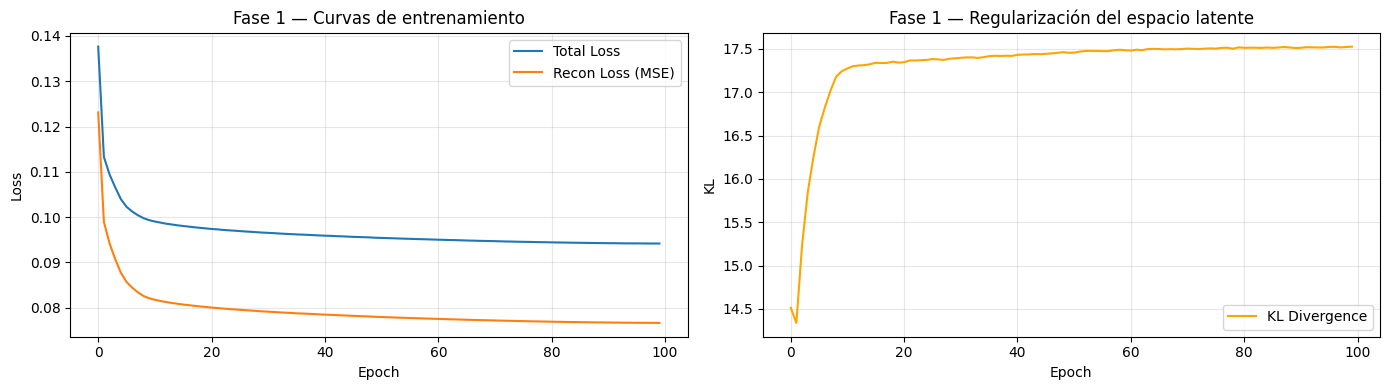


✅ Fase 1 completada.
   Recon Loss final: 0.0766
   KL final:         17.5258


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history_p1['loss'],  label='Total Loss')
ax1.plot(history_p1['recon'], label='Recon Loss (MSE)')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Fase 1 — Curvas de entrenamiento')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history_p1['kl'], color='orange', label='KL Divergence')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('KL')
ax2.set_title('Fase 1 — Regularización del espacio latente')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Fase 1 completada.")
print(f"   Recon Loss final: {history_p1['recon'][-1]:.4f}")
print(f"   KL final:         {history_p1['kl'][-1]:.4f}")

In [13]:
# --- Al final de la celda cell-loader-p1 ---
clean_ds     = TensorDataset(all_clean_norm)
clean_loader = DataLoader(clean_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)

print(f"✅ DataLoader Fase 1: {len(clean_loader)} batches")

# 🗑️ LIMPIEZA DE RAM AHORA:
import gc
del clean_frames_list
del all_clean
del all_clean_norm
gc.collect()
print("🧹 RAM liberada tras cargar Fase 1")

✅ DataLoader Fase 1: 1836 batches
🧹 RAM liberada tras cargar Fase 1


---
## PASO 7 — Preparación de Fase 2: Pares ruidoso-limpio

Usamos la **misma** función de preprocesamiento y la **misma** normalización (MEAN_P, STD_P)
para los datos ruidosos. Esto es crítico: si normalizamos con estadísticas distintas,
el NA-Encoder aprende a mapear un espacio diferente al del encoder original.

Fang et al. (Sec. 4.3):
> *"Global normalization to zero mean and unit standard deviation is employed for training the noise-aware encoder, since Kullback–Leibler divergence is scale-dependent."*

In [14]:
print(f"⏳ Cargando {N_TRAIN} pares (clean + noisy) para Fase 2...")
clean_p2_list = []
noisy_p2_list = []

for i, fname in enumerate(train_files[:N_TRAIN]):
    c = audio_to_logpower(os.path.join(path_train_clean, fname))
    n = audio_to_logpower(os.path.join(path_train_noisy, fname))

    # Alinear longitud temporal (pueden diferir por 1-2 frames al borde)
    min_t = min(c.shape[0], n.shape[0])
    clean_p2_list.append(c[:min_t])
    noisy_p2_list.append(n[:min_t])

    if (i + 1) % 1000 == 0:
        print(f"  {i+1}/{N_TRAIN} pares procesados")

all_clean_p2 = torch.cat(clean_p2_list, dim=0)
all_noisy_p2 = torch.cat(noisy_p2_list, dim=0)

# Normalizar AMBOS con las mismas estadísticas de Fase 1 (MEAN_P, STD_P)
all_clean_p2_norm = (all_clean_p2 - MEAN_P) / (STD_P + 1e-8)
all_noisy_p2_norm = (all_noisy_p2 - MEAN_P) / (STD_P + 1e-8)

phase2_ds     = TensorDataset(all_noisy_p2_norm, all_clean_p2_norm)
phase2_loader = DataLoader(phase2_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True)

print(f"\n✅ Fase 2 lista. Frames: {all_clean_p2.shape[0]:,}")
print(f"   Loader: {len(phase2_loader)} batches")

⏳ Cargando 2500 pares (clean + noisy) para Fase 2...
  1000/2500 pares procesados
  2000/2500 pares procesados

✅ Fase 2 lista. Frames: 469,807
   Loader: 1836 batches


---
## PASO 8 — Noise-Aware Encoder

Fang et al. (2021), Sec. 3:
> *"The noise-aware encoder has the **same structure** as the speech-based encoder of the standard VAE."*

La pérdida de Fase 2 es la divergencia KL entre la distribución del encoder limpio
(fija, congelada) y la del NA-Encoder sobre audio ruidoso (eq. 7-8 del paper):

$$\mathcal{L}(\gamma) = \sum_t D_{KL}[q_\phi(z_t|s_t) \| q_\gamma(z_t|x_t)]$$

El **decoder permanece congelado** en toda la Fase 2.

In [15]:
# ── NA-Encoder: misma arquitectura, inicializado desde el encoder limpio ───────
# Fang et al.: inicializar desde el encoder pre-entrenado es clave para converger
na_encoder = copy.deepcopy(vae.encoder_net).to(DEVICE)
na_mu      = copy.deepcopy(vae.fc_mu).to(DEVICE)
na_logvar  = copy.deepcopy(vae.fc_logvar).to(DEVICE)

# ── Congelar el VAE original (decoder Y encoder clean) ─────────────────────────
# El decoder NO se toca en ningún momento — es el "artista" que aprendió la voz
vae.eval()
for param in vae.parameters():
    param.requires_grad = False

# Solo entrenamos el NA-Encoder
na_params      = (list(na_encoder.parameters()) +
                  list(na_mu.parameters()) +
                  list(na_logvar.parameters()))
optimizer_p2   = torch.optim.Adam(na_params, lr=LR_P2)
scheduler_p2   = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=EPOCHS_P2, eta_min=LR_P2 * 0.1
)

n_na = sum(p.numel() for p in na_params)
print(f"✅ NA-Encoder: {n_na:,} parámetros entrenables")
print(f"   Decoder congelado: {sum(p.numel() for p in vae.decoder_net.parameters()):,} parámetros")

✅ NA-Encoder: 86,432 parámetros entrenables
   Decoder congelado: 84,865 parámetros


In [16]:
def kl_two_gaussians(mu_clean, logvar_clean, mu_noisy, logvar_noisy):
    """
    Divergencia KL entre dos Gaussianas: KL[q_φ(z|s) || q_γ(z|x)]
    Fang et al. (2021), eq. 7-8.

    KL[N(μ1,σ1²) || N(μ2,σ2²)] = log(σ2/σ1) + (σ1² + (μ1-μ2)²)/(2σ2²) - 1/2
    """
    var_c = logvar_clean.exp()   # σ²_clean
    var_n = logvar_noisy.exp()   # σ²_noisy

    kl = 0.5 * (
        logvar_noisy - logvar_clean          # log(σ_n / σ_c)
        - 1.0
        + (var_c + (mu_clean - mu_noisy).pow(2)) / (var_n + 1e-8)
    )
    return torch.mean(torch.sum(kl, dim=1))

---
## PASO 9 — Entrenamiento Fase 2: NA-Encoder

In [19]:
def train_phase2(vae_clean, na_enc, na_m, na_v, loader,
                 optimizer, scheduler, epochs=EPOCHS_P2):
    history = []

    na_enc.train(); na_m.train(); na_v.train()

    for epoch in range(epochs):
        total_loss = 0.0

        for noisy_x, clean_x in loader:
            noisy_x = noisy_x.to(DEVICE)
            clean_x = clean_x.to(DEVICE)

            # "Profesor": encoder limpio (congelado) — distribución objetivo
            with torch.no_grad():
                h_c    = vae_clean.encoder_net(clean_x)
                mu_c   = vae_clean.fc_mu(h_c)
                lv_c   = vae_clean.fc_logvar(h_c)

            # "Alumno": NA-Encoder (entrenando) — imitar desde audio ruidoso
            h_n  = na_enc(noisy_x)
            mu_n = na_m(h_n)
            lv_n = na_v(h_n)

            loss = kl_two_gaussians(mu_c, lv_c, mu_n, lv_n)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(na_params, max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        scheduler.step()
        avg = total_loss / len(loader)
        history.append(avg)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"Epoch [{epoch+1:3d}/{epochs}] | KL(noisy→clean): {avg:.4f} | lr: {lr_now:.2e}")

    return history


print("🔥 Iniciando Fase 2: Entrenamiento del Noise-Aware Encoder...")
print(f"   Objetivo: minimizar KL[q_φ(z|s) || q_γ(z|x)] (Fang et al. eq. 7)\n")
history_p2 = train_phase2(vae, na_encoder, na_mu, na_logvar,
                           phase2_loader, optimizer_p2, scheduler_p2)

🔥 Iniciando Fase 2: Entrenamiento del Noise-Aware Encoder...
   Objetivo: minimizar KL[q_φ(z|s) || q_γ(z|x)] (Fang et al. eq. 7)

Epoch [  1/100] | KL(noisy→clean): 12.0450 | lr: 7.16e-05
Epoch [  5/100] | KL(noisy→clean): 11.9783 | lr: 6.06e-05
Epoch [ 10/100] | KL(noisy→clean): 11.9164 | lr: 4.66e-05
Epoch [ 15/100] | KL(noisy→clean): 11.8708 | lr: 3.33e-05
Epoch [ 20/100] | KL(noisy→clean): 11.8401 | lr: 2.22e-05
Epoch [ 25/100] | KL(noisy→clean): 11.8178 | lr: 1.43e-05
Epoch [ 30/100] | KL(noisy→clean): 11.8055 | lr: 1.04e-05
Epoch [ 35/100] | KL(noisy→clean): 11.7974 | lr: 1.08e-05
Epoch [ 40/100] | KL(noisy→clean): 11.7913 | lr: 1.56e-05
Epoch [ 45/100] | KL(noisy→clean): 11.7840 | lr: 2.42e-05
Epoch [ 50/100] | KL(noisy→clean): 11.7743 | lr: 3.58e-05
Epoch [ 55/100] | KL(noisy→clean): 11.7594 | lr: 4.94e-05
Epoch [ 60/100] | KL(noisy→clean): 11.7395 | lr: 6.34e-05
Epoch [ 65/100] | KL(noisy→clean): 11.7158 | lr: 7.67e-05
Epoch [ 70/100] | KL(noisy→clean): 11.6866 | lr: 8.78e-05


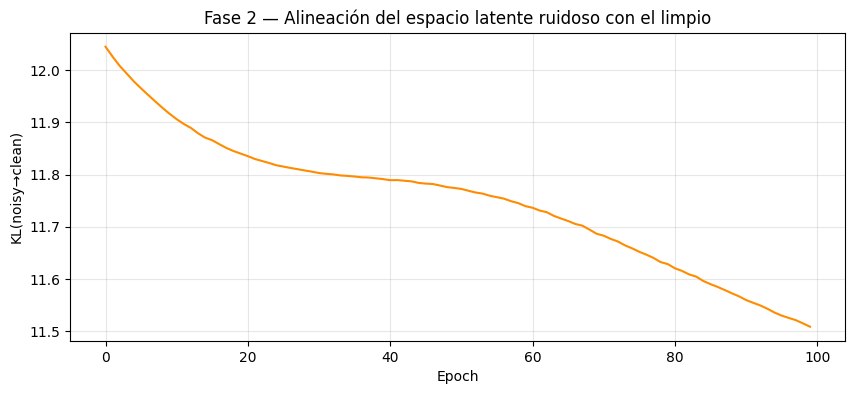


✅ Fase 2 completada.
   KL inicial: 12.0450  →  KL final: 11.5084
   Reducción: 4.5%


In [20]:
plt.figure(figsize=(10, 4))
plt.plot(history_p2, color='darkorange')
plt.xlabel('Epoch'); plt.ylabel('KL(noisy→clean)')
plt.title('Fase 2 — Alineación del espacio latente ruidoso con el limpio')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n✅ Fase 2 completada.")
print(f"   KL inicial: {history_p2[0]:.4f}  →  KL final: {history_p2[-1]:.4f}")
print(f"   Reducción: {(1 - history_p2[-1]/history_p2[0])*100:.1f}%")

---
## PASO 10 — Inferencia: Filtro de Wiener con estimación NMF del ruido

Fang et al. (2021), eq. 6 — Filtro de Wiener óptimo:

$$\hat{m}_{ft} = \frac{\hat{\sigma}^2_s(z_t)}{g_t \hat{\sigma}^2_s(z_t) + \sum_k w_{fk} h_{kt}}$$

Donde:
- $\hat{\sigma}^2_s(z_t)$: varianza de la voz estimada por el decoder del VAE
- $\sum_k w_{fk} h_{kt}$: varianza del ruido estimada por NMF no supervisado
- $g_t$: ganancia frame-dependiente (normaliza la energía)

Esta formulación es **muy diferente** de `P_clean / (P_clean + α·P_noisy)` usada antes:
el denominador usa la **potencia estimada del ruido** (NMF), no un múltiplo de la mezcla.

In [21]:
def estimate_noise_psd_nmf(stft_noisy_mag, rank=NMF_RANK, n_iter=200):
    """
    Estimación no supervisada de la varianza del ruido mediante NMF.
    Fang et al. (2021), Sec. 2.3.

    Descompone |X|² ≈ W·H  donde W ∈ R^{F×K} y H ∈ R^{K×T}
    Retorna la reconstrucción W·H como estimación de σ²_n  [F, T]
    """
    V = stft_noisy_mag ** 2  # Potencia de la mezcla [F, T]
    V = np.maximum(V, 1e-10) # Evitar ceros en NMF

    # NMF con divergencia β=1 (Itakura-Saito se aproxima con β-divergencia)
    # Usamos 'kullback-leibler' que funciona bien para espectros de potencia
    model_nmf = NMF(n_components=rank, beta_loss='kullback-leibler',
                    solver='mu', max_iter=n_iter, init='nndsvda',
                    random_state=42)
    W = model_nmf.fit_transform(V)  # [F, K]
    H = model_nmf.components_       # [K, T]

    sigma_n_sq = W @ H  # [F, T] — varianza del ruido estimada
    return np.maximum(sigma_n_sq, 1e-10)

In [22]:
@torch.no_grad()
def denoise_navae(file_path, vae_model, na_enc, na_m, use_nmf=True):
    """
    Pipeline completo de speech enhancement con NA-VAE + Wiener (Fang et al. 2021).

    1. STFT de la señal ruidosa
    2. NA-Encoder: obtiene z_t desde el audio ruidoso
    3. Decoder: estima σ²_s(z_t) — varianza de la voz limpia
    4. NMF: estima σ²_n — varianza del ruido
    5. Wiener filter (eq. 6): máscara óptima
    6. ISTFT: reconstruye la señal limpia
    """
    na_enc.eval(); na_m.eval()

    # ── 1. STFT ───────────────────────────────────────────────────────────────
    y_noisy, _ = librosa.load(file_path, sr=SR)
    window     = np.sin(np.pi * (np.arange(WIN_LENGTH) + 0.5) / WIN_LENGTH).astype(np.float32)
    stft_noisy = librosa.stft(y_noisy, n_fft=N_FFT, hop_length=HOP_LENGTH,
                               win_length=WIN_LENGTH, window=window)  # [F, T] complex

    # ── 2. Preprocesar y pasar por NA-Encoder ─────────────────────────────────
    log_pow   = np.log10(np.abs(stft_noisy)**2 + 1e-8).astype(np.float32)  # [F, T]
    norm_in   = (torch.from_numpy(log_pow.T).to(DEVICE) - MEAN_P) / (STD_P + 1e-8)  # [T, F]

    h_n = na_enc(norm_in)
    # Durante inferencia: usamos solo μ (sin reparametrizar) — Fang et al. Sec. 3
    z_t = na_m(h_n)  # [T, LATENT_DIM]

    # ── 3. Decoder: estima σ²_s en escala log-power normalizada ───────────────
    log_pow_norm_est = vae_model.decode(z_t)  # [T, F] — escala normalizada

    # Desnormalizar → log-power real
    log_pow_est = (log_pow_norm_est * STD_P + MEAN_P).cpu().numpy()  # [T, F]

    # Convertir a potencia lineal: σ²_s = 10^(log10(σ²_s))
    sigma_s_sq = np.maximum(10.0 ** log_pow_est.T, 1e-10)  # [F, T]

    # ── 4. Estimación de σ²_n (NMF o approximación simple) ───────────────────
    if use_nmf:
        sigma_n_sq = estimate_noise_psd_nmf(np.abs(stft_noisy))  # [F, T]
    else:
        # Aproximación simple: mediana temporal (zonas de silencio ≈ ruido puro)
        power_mix   = np.abs(stft_noisy) ** 2
        sigma_n_sq  = np.median(power_mix, axis=1, keepdims=True) * np.ones_like(power_mix)
        sigma_n_sq  = np.maximum(sigma_n_sq, 1e-10)

    # ── 5. Estimación de ganancia g_t (frame-dependiente) ─────────────────────
    # g_t normaliza la loudness: g_t = E[|x_ft|²] / (σ²_s(z_t) + σ²_n)
    # Estimamos como ratio de energías de mezcla y modelo
    power_mix  = np.abs(stft_noisy) ** 2  # [F, T]
    model_sum  = sigma_s_sq + sigma_n_sq  # [F, T]
    g_t        = (power_mix.mean(axis=0, keepdims=True) /
                  (model_sum.mean(axis=0, keepdims=True) + 1e-10))  # [1, T]
    g_t        = np.clip(g_t, 0.01, 10.0)  # Limitar para estabilidad numérica

    # ── 6. Filtro de Wiener (Fang et al. eq. 6) ───────────────────────────────
    # mask_ft = σ²_s(z_t) / (g_t·σ²_s(z_t) + σ²_n)
    mask = sigma_s_sq / (g_t * sigma_s_sq + sigma_n_sq + 1e-10)  # [F, T]

    # Suavizado temporal de la máscara (reduce ruido musical)
    mask = uniform_filter1d(mask, size=3, axis=1)
    mask = np.clip(mask, 0.0, 1.0)

    # ── 7. Reconstrucción ─────────────────────────────────────────────────────
    stft_enhanced = stft_noisy * mask
    y_enhanced    = librosa.istft(stft_enhanced, hop_length=HOP_LENGTH,
                                   win_length=WIN_LENGTH, window=window)

    # Normalización de amplitud (evita clipping)
    peak = np.max(np.abs(y_enhanced))
    if peak > 0:
        y_enhanced = y_enhanced / peak * 0.85

    return y_noisy, y_enhanced, sigma_s_sq, mask

---
## PASO 11 — Evaluación: Métricas y visualización

In [23]:
def snr_improvement(clean, noisy, enhanced):
    """Mejora de SNR en dB: SNR_after - SNR_before"""
    min_len = min(len(clean), len(noisy), len(enhanced))
    c = clean[:min_len]
    n = noisy[:min_len]
    e = enhanced[:min_len]

    snr_in  = 10 * np.log10(np.sum(c**2) / (np.sum((c - n)**2) + 1e-10))
    snr_out = 10 * np.log10(np.sum(c**2) / (np.sum((c - e)**2) + 1e-10))
    return snr_out - snr_in, snr_in, snr_out


def plot_results(file_name, use_nmf=True):
    path_c = os.path.join(path_test_clean, file_name)
    path_n = os.path.join(path_test_noisy, file_name)

    y_noisy, y_enhanced, sigma_s, mask = denoise_navae(
        path_n, vae, na_encoder, na_mu, use_nmf=use_nmf
    )
    y_clean, _ = librosa.load(path_c, sr=SR)

    delta_snr, snr_in, snr_out = snr_improvement(y_clean, y_noisy, y_enhanced)

    fig, axes = plt.subplots(1, 4, figsize=(22, 4))

    specs = [
        (y_noisy,    "Ruidoso (entrada)",    'Reds_r'),
        (y_clean,    "Limpio (referencia)",   'Blues_r'),
        (y_enhanced, "NA-VAE + Wiener",       'Greens_r'),
    ]
    for ax, (sig, title, cmap) in zip(axes[:3], specs):
        D = librosa.amplitude_to_db(np.abs(librosa.stft(sig, n_fft=N_FFT)), ref=np.max)
        librosa.display.specshow(D, sr=SR, x_axis='time', y_axis='hz', ax=ax, cmap=cmap)
        ax.set_title(title, fontsize=11)

    # Máscara de Wiener
    im = axes[3].imshow(mask, aspect='auto', origin='lower',
                         vmin=0, vmax=1, cmap='plasma')
    axes[3].set_title('Máscara de Wiener (eq. 6)', fontsize=11)
    axes[3].set_xlabel('Frames temporales')
    axes[3].set_ylabel('Bins de frecuencia')
    plt.colorbar(im, ax=axes[3])

    plt.suptitle(f"{file_name}  |  SNR: {snr_in:.1f} dB → {snr_out:.1f} dB  (Δ = +{delta_snr:.2f} dB)",
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"🔊 Ruidoso:")
    display(ipd.Audio(y_noisy, rate=SR))
    print(f"🔊 Enhanced (NA-VAE):")
    display(ipd.Audio(y_enhanced, rate=SR))

    return delta_snr


# Evaluar 5 ejemplos del set de test
print("📊 Evaluando ejemplos del set de test...\n")
for sample in test_files[:5]:
    print(f"\n{'─'*60}")
    plot_results(sample, use_nmf=True)

Output hidden; open in https://colab.research.google.com to view.

In [24]:
def evaluate_batch(n_samples=50, use_nmf=True):
    """
    Evaluación en lote: SNR improvement sobre n_samples audios de test.
    """
    results = []
    print(f"🔍 Evaluando {n_samples} audios (NMF={'Sí' if use_nmf else 'No'})...\n")

    for fname in test_files[:n_samples]:
        path_c = os.path.join(path_test_clean, fname)
        path_n = os.path.join(path_test_noisy, fname)

        y_noisy, y_enhanced, _, _ = denoise_navae(
            path_n, vae, na_encoder, na_mu, use_nmf=use_nmf
        )
        y_clean, _ = librosa.load(path_c, sr=SR)

        delta_snr, snr_in, snr_out = snr_improvement(y_clean, y_noisy, y_enhanced)
        mse = np.mean((y_clean[:min(len(y_clean), len(y_enhanced))] -
                        y_enhanced[:min(len(y_clean), len(y_enhanced))])**2)

        results.append({'file': fname, 'delta_snr': delta_snr,
                        'snr_in': snr_in, 'snr_out': snr_out, 'mse': mse})
        print(f"  {fname:25s}  SNR: {snr_in:+.1f} → {snr_out:+.1f} dB  (Δ={delta_snr:+.2f})  MSE={mse:.5f}")

    df = pd.DataFrame(results)
    print(f"\n{'═'*60}")
    print(f"📊 RESUMEN ({n_samples} audios)")
    print(f"   Δ SNR medio:  {df['delta_snr'].mean():+.2f} dB  (σ={df['delta_snr'].std():.2f})")
    print(f"   SNR entrada:  {df['snr_in'].mean():.2f} dB")
    print(f"   SNR salida:   {df['snr_out'].mean():.2f} dB")
    print(f"   MSE medio:    {df['mse'].mean():.6f}")
    print(f"{'═'*60}")

    return df


df_results = evaluate_batch(n_samples=50, use_nmf=True)

🔍 Evaluando 50 audios (NMF=Sí)...

  p232_001.wav               SNR: +15.6 → +1.4 dB  (Δ=-14.30)  MSE=0.00603
  p232_002.wav               SNR: +11.3 → +3.2 dB  (Δ=-8.13)  MSE=0.00391
  p232_003.wav               SNR: +6.7 → +3.7 dB  (Δ=-3.02)  MSE=0.00211
  p232_005.wav               SNR: +1.9 → +1.2 dB  (Δ=-0.66)  MSE=0.00498
  p232_006.wav               SNR: +16.9 → -1.9 dB  (Δ=-18.83)  MSE=0.00647
  p232_007.wav               SNR: +11.8 → +1.5 dB  (Δ=-10.30)  MSE=0.00383
  p232_009.wav               SNR: +6.8 → +2.1 dB  (Δ=-4.64)  MSE=0.00510
  p232_010.wav               SNR: +0.9 → +2.8 dB  (Δ=+1.89)  MSE=0.00299
  p232_011.wav               SNR: +16.9 → +2.3 dB  (Δ=-14.54)  MSE=0.00403
  p232_012.wav               SNR: +11.9 → -1.8 dB  (Δ=-13.75)  MSE=0.00526
  p232_013.wav               SNR: +6.8 → +1.9 dB  (Δ=-4.87)  MSE=0.00442
  p232_014.wav               SNR: +2.0 → +1.6 dB  (Δ=-0.43)  MSE=0.00287
  p232_015.wav               SNR: +16.9 → +2.8 dB  (Δ=-14.17)  MSE=0.00349
  p

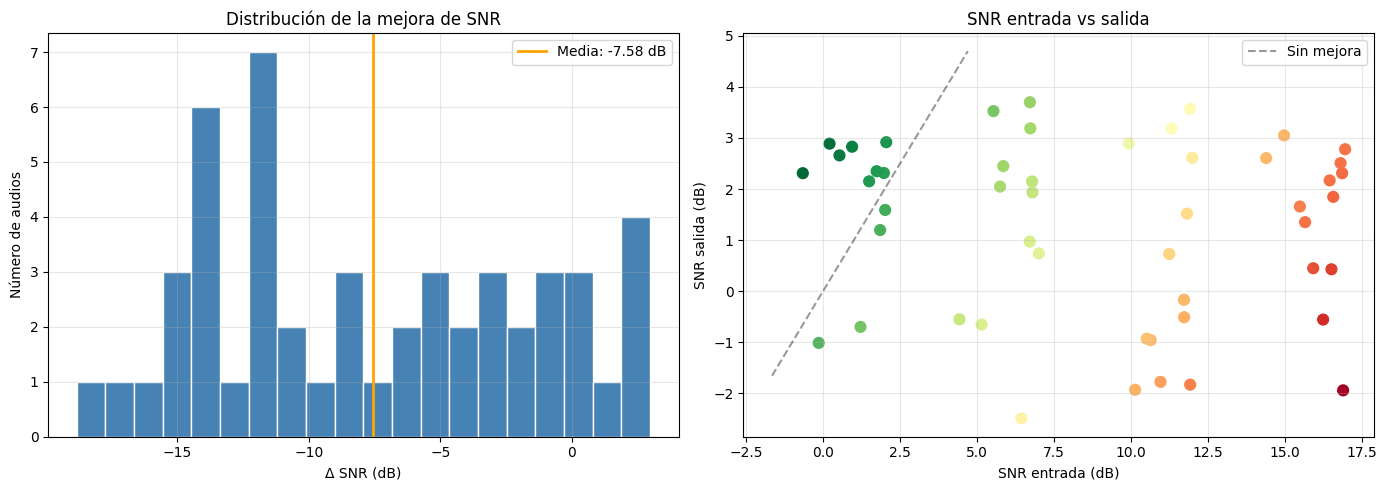

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(df_results['delta_snr'], bins=20, color='steelblue', edgecolor='white')
ax1.axvline(df_results['delta_snr'].mean(), color='orange', linewidth=2,
             label=f"Media: {df_results['delta_snr'].mean():+.2f} dB")
ax1.set_xlabel('Δ SNR (dB)')
ax1.set_ylabel('Número de audios')
ax1.set_title('Distribución de la mejora de SNR')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.scatter(df_results['snr_in'], df_results['snr_out'],
             c=df_results['delta_snr'], cmap='RdYlGn', s=60)
lims = [df_results['snr_in'].min() - 1, df_results['snr_out'].max() + 1]
ax2.plot(lims, lims, 'k--', alpha=0.4, label='Sin mejora')
ax2.set_xlabel('SNR entrada (dB)')
ax2.set_ylabel('SNR salida (dB)')
ax2.set_title('SNR entrada vs salida')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## PASO 12 — Ablation Study: NMF vs aproximación simple

Para el blog: comparamos el filtro de Wiener usando NMF (como el paper) vs la aproximación
de mediana espectral, para cuantificar el aporte de cada componente.

🔬 Ablation Study: NMF vs Aproximación simple de ruido
   Evaluando 20 audios con cada configuración...


  NMF (Fang et al.):   Δ SNR = -7.71 dB  (σ=6.17)
  Aproximación simple: Δ SNR = -5.58 dB  (σ=6.14)


/tmp/ipykernel_937/2810062998.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([deltas_simple, deltas_nmf],


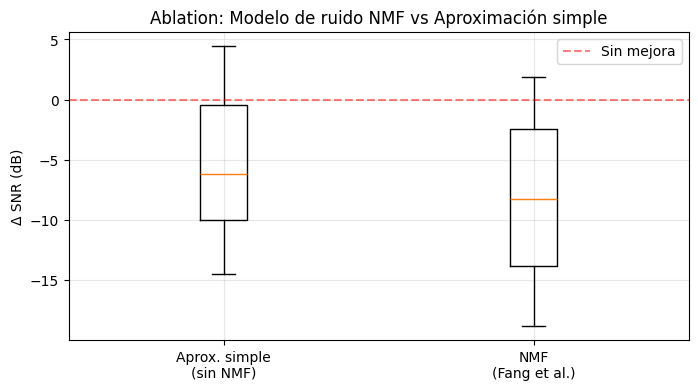

In [26]:
print("🔬 Ablation Study: NMF vs Aproximación simple de ruido")
print("   Evaluando 20 audios con cada configuración...\n")

sample_subset = test_files[:20]

def quick_eval(use_nmf, files):
    deltas = []
    for fname in files:
        path_c = os.path.join(path_test_clean, fname)
        path_n = os.path.join(path_test_noisy, fname)
        y_noisy, y_enhanced, _, _ = denoise_navae(
            path_n, vae, na_encoder, na_mu, use_nmf=use_nmf
        )
        y_clean, _ = librosa.load(path_c, sr=SR)
        d, _, _ = snr_improvement(y_clean, y_noisy, y_enhanced)
        deltas.append(d)
    return deltas

deltas_nmf    = quick_eval(use_nmf=True,  files=sample_subset)
deltas_simple = quick_eval(use_nmf=False, files=sample_subset)

print(f"\n  NMF (Fang et al.):   Δ SNR = {np.mean(deltas_nmf):+.2f} dB  (σ={np.std(deltas_nmf):.2f})")
print(f"  Aproximación simple: Δ SNR = {np.mean(deltas_simple):+.2f} dB  (σ={np.std(deltas_simple):.2f})")

plt.figure(figsize=(8, 4))
plt.boxplot([deltas_simple, deltas_nmf],
             labels=['Aprox. simple\n(sin NMF)', 'NMF\n(Fang et al.)'])
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Sin mejora')
plt.ylabel('Δ SNR (dB)')
plt.title('Ablation: Modelo de ruido NMF vs Aproximación simple')
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

---
## PASO 13 — Guardar checkpoint

In [ ]:
checkpoint_path = '/content/drive/MyDrive/BlogPASD/navae_fang2021_v2.pth'

checkpoint = {
    # Modelos
    'vae_state_dict':       vae.state_dict(),
    'na_encoder_state_dict': na_encoder.state_dict(),
    'na_mu_state_dict':     na_mu.state_dict(),
    'na_logvar_state_dict': na_logvar.state_dict(),
    # Estadísticas de normalización (imprescindibles para inferencia)
    'mean_p':               MEAN_P,
    'std_p':                STD_P,
    # Hiperparámetros del paper
    'latent_dim':           LATENT_DIM,
    'hidden_dim':           HIDDEN_DIM,
    'n_fft':                N_FFT,
    'hop_length':           HOP_LENGTH,
    'sr':                   SR,
    # Historial
    'history_p1':           history_p1,
    'history_p2':           history_p2,
}

torch.save(checkpoint, checkpoint_path)
print(f"✅ Checkpoint guardado en: {checkpoint_path}")

---
## Resumen de correcciones implementadas

### Basadas en Fang et al. (2021) — *VAE for Speech Enhancement with a Noise-Aware Encoder*

1. **Activación `Tanh`** en encoder y decoder (Sec. 4.3): más suave que LeakyReLU para espacios latentes continuos, evita saturación en los extremos del espectro logarítmico.

2. **`LATENT_DIM=16`** (Sec. 4.3): el paper fija D=16 explícitamente. Usar 32 introduce redundancia innecesaria y dificulta la regularización KL.

3. **β=1 con warmup** (eq. 3): el ELBO estándar regula mejor el espacio latente que β=0.1. El warmup de 10 épocas evita el colapso posterior al inicio del entrenamiento.

4. **Normalización consistente** (Sec. 4.3): los datos ruidosos en Fase 2 se normalizan con la MISMA μ/σ calculada en Fase 1 sobre datos limpios. La KL divergencia es sensible a la escala.

5. **Filtro de Wiener correcto** (eq. 6): `σ²_s / (g_t·σ²_s + σ²_n)` en lugar de `P_clean / (P_clean + α·P_noisy)`. La diferencia clave: el denominador usa la estimación del ruido (NMF), no un múltiplo de la mezcla.

6. **NMF para modelo de ruido** (Sec. 2.3, K=8): estimación no supervisada de la varianza del ruido, independiente del tipo de ruido en test. Esto es lo que da robustez a condiciones de ruido no vistas.

7. **Ganancia frame-dependiente g_t** (eq. 6): normaliza las diferencias de energía entre clips, haciendo el sistema robusto a la loudness variable del dataset.

8. **Eliminación del fine-tuning**: descongelar el decoder en Fase 2 destruye el prior generativo aprendido. El decoder debe permanecer congelado para que la interpretación VAE-NMF sea válida.

9. **Gradient clipping** y **CosineAnnealing LR**: estabilizan el entrenamiento en ambas fases sin hiperparámetros adicionales.

### Referencias
- Fang et al. (2021). *Variational Autoencoder for Speech Enhancement with a Noise-Aware Encoder*. ICASSP 2021.
- Leglaive et al. (2018). *A Variance Modeling Framework based on Variational Autoencoders for Speech Enhancement*. MLSP 2018.
- Kingma & Welling (2014). *Auto-Encoding Variational Bayes*. ICLR 2014.

In [28]:
# Ordenar df_results por Δ SNR descendente y ver el top
df_top = df_results.sort_values('delta_snr', ascending=False).reset_index(drop=True)

print("🏆 TOP 10 audios con mejor Δ SNR\n")
print(f"{'#':<4} {'Archivo':<30} {'SNR entrada':>12} {'SNR salida':>12} {'Δ SNR':>10}")
print("─" * 72)
for i, row in df_top.head(10).iterrows():
    print(f"{i+1:<4} {row['file']:<30} {row['snr_in']:>+11.2f} dB {row['snr_out']:>+10.2f} dB {row['delta_snr']:>+9.2f} dB")

🏆 TOP 10 audios con mejor Δ SNR

#    Archivo                         SNR entrada   SNR salida      Δ SNR
────────────────────────────────────────────────────────────────────────
1    p232_048.wav                         -0.66 dB      +2.31 dB     +2.97 dB
2    p232_028.wav                         +0.21 dB      +2.89 dB     +2.68 dB
3    p232_040.wav                         +0.53 dB      +2.66 dB     +2.13 dB
4    p232_010.wav                         +0.94 dB      +2.83 dB     +1.89 dB
5    p232_019.wav                         +2.05 dB      +2.92 dB     +0.86 dB
6    p232_036.wav                         +1.50 dB      +2.15 dB     +0.65 dB
7    p232_032.wav                         +1.74 dB      +2.35 dB     +0.61 dB
8    p232_023.wav                         +1.97 dB      +2.31 dB     +0.34 dB
9    p232_014.wav                         +2.02 dB      +1.59 dB     -0.43 dB
10   p232_005.wav                         +1.85 dB      +1.20 dB     -0.66 dB


In [31]:
from IPython.display import display, Audio

TOP_N = 3

for i, row in df_top.head(TOP_N).iterrows():
    fname = row['file']
    path_c = os.path.join(path_test_clean, fname)
    path_n = os.path.join(path_test_noisy, fname)

    y_noisy, y_enhanced, _, _ = denoise_navae(
        path_n, vae, na_encoder, na_mu, use_nmf=True
    )
    y_clean, _ = librosa.load(path_c, sr=SR)

    print(f"\n{'═'*60}")
    print(f"#{i+1}  {fname}")
    print(f"    SNR entrada: {row['snr_in']:+.2f} dB  →  salida: {row['snr_out']:+.2f} dB  (Δ = {row['delta_snr']:+.2f} dB)")
    print(f"{'─'*60}")
    print("🔴 Ruidoso (entrada):")
    display(Audio(y_noisy, rate=SR))
    print("🟢 Enhanced (NA-VAE):")
    display(Audio(y_enhanced, rate=SR))
    print("🔵 Limpio (referencia):")
    display(Audio(y_clean, rate=SR))


════════════════════════════════════════════════════════════
#1  p232_048.wav
    SNR entrada: -0.66 dB  →  salida: +2.31 dB  (Δ = +2.97 dB)
────────────────────────────────────────────────────────────
🔴 Ruidoso (entrada):


🟢 Enhanced (NA-VAE):


🔵 Limpio (referencia):



════════════════════════════════════════════════════════════
#2  p232_028.wav
    SNR entrada: +0.21 dB  →  salida: +2.89 dB  (Δ = +2.68 dB)
────────────────────────────────────────────────────────────
🔴 Ruidoso (entrada):


🟢 Enhanced (NA-VAE):


🔵 Limpio (referencia):



════════════════════════════════════════════════════════════
#3  p232_040.wav
    SNR entrada: +0.53 dB  →  salida: +2.66 dB  (Δ = +2.13 dB)
────────────────────────────────────────────────────────────
🔴 Ruidoso (entrada):


🟢 Enhanced (NA-VAE):


🔵 Limpio (referencia):


In [32]:
import soundfile as sf
import subprocess
from google.colab import files


output_dir = '/content/drive/MyDrive/BlogPASD/blog_audiosV1'
os.makedirs(output_dir, exist_ok=True)

for i, row in df_top.head(TOP_N).iterrows():
    fname  = row['file']
    stem   = fname.replace('.wav', '')
    path_n = os.path.join(path_test_noisy, fname)

    y_noisy, y_enhanced, _, _ = denoise_navae(
        path_n, vae, na_encoder, na_mu, use_nmf=True
    )

    for tag, audio in [('noisy', y_noisy), ('enhanced', y_enhanced)]:
        wav_path = f'{output_dir}/{stem}_{tag}.wav'
        mp3_path = f'{output_dir}/{stem}_{tag}.mp3'

        sf.write(wav_path, audio, SR)
        subprocess.run(
            ['ffmpeg', '-y', '-i', wav_path, '-b:a', '128k', mp3_path],
            capture_output=True
        )
        os.remove(wav_path)  # borra el WAV intermedio, solo queda el MP3
        print(f'✅ {mp3_path}')

# Descarga todos los MP3 de una vez
print("\n📥 Descargando archivos...")
for f in sorted(os.listdir(output_dir)):
    if f.endswith('.mp3'):
        files.download(f'{output_dir}/{f}')

✅ /content/drive/MyDrive/BlogPASD/blog_audiosV1/p232_048_noisy.mp3
✅ /content/drive/MyDrive/BlogPASD/blog_audiosV1/p232_048_enhanced.mp3
✅ /content/drive/MyDrive/BlogPASD/blog_audiosV1/p232_028_noisy.mp3
✅ /content/drive/MyDrive/BlogPASD/blog_audiosV1/p232_028_enhanced.mp3
✅ /content/drive/MyDrive/BlogPASD/blog_audiosV1/p232_040_noisy.mp3
✅ /content/drive/MyDrive/BlogPASD/blog_audiosV1/p232_040_enhanced.mp3

📥 Descargando archivos...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>